In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Insaurance Fraud Data.xlsx")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [4]:
# Create copy
df_clean = df.copy()

In [5]:
# Clean column names
df_clean.columns = df_clean.columns.str.lower().str.replace(" ", "_")

In [6]:
# Replace ? with NaN
df_clean.replace("?", np.nan, inplace=True)

In [7]:
# Fill important categorical columns
important_cat = [
    "authorities_contacted",
    "police_report_available",
    "property_damage",
    "collision_type"
]

for col in important_cat:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [8]:
# Fill remaining categorical columns
cat_cols = df_clean.select_dtypes(include="object").columns

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [9]:
# Fill numeric columns
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [10]:
# Remove duplicates
df_clean.drop_duplicates(inplace=True)

In [11]:
# Create fraud flag
df_clean["fraud_flag"] = df_clean["fraud_reported"].map({"Y": 1, "N": 0})

In [12]:
# Create age group
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "50+"]
)

In [13]:
# Create claim premium ratio
df_clean["claim_premium_ratio"] = (
    df_clean["total_claim_amount"] / df_clean["policy_annual_premium"]
)

In [14]:
# Extract date parts
df_clean["incident_month"] = df_clean["incident_date"].dt.month
df_clean["incident_year"] = df_clean["incident_date"].dt.year

In [15]:
# Create high claim flag
df_clean["high_claim_flag"] = (
    df_clean["total_claim_amount"] > df_clean["total_claim_amount"].median()
).astype(int)

In [16]:
# Final check
print(df_clean.shape)
print(df_clean.isnull().sum().sum())
df_clean.head()

(1000, 45)
0


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,auto_make,auto_model,auto_year,fraud_reported,fraud_flag,age_group,claim_premium_ratio,incident_month,incident_year,high_claim_flag
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,Saab,92x,2004,Y,1,36-50,50.898778,1,2015,1
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,Mercedes,E400,2007,Y,1,36-50,4.234811,1,2015,0
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,Dodge,RAM,2007,N,0,26-35,24.519864,2,2015,0
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,Chevrolet,Tahoe,2014,Y,1,36-50,44.782234,1,2015,1
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,Accura,RSX,2009,N,0,36-50,4.103769,2,2015,0


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

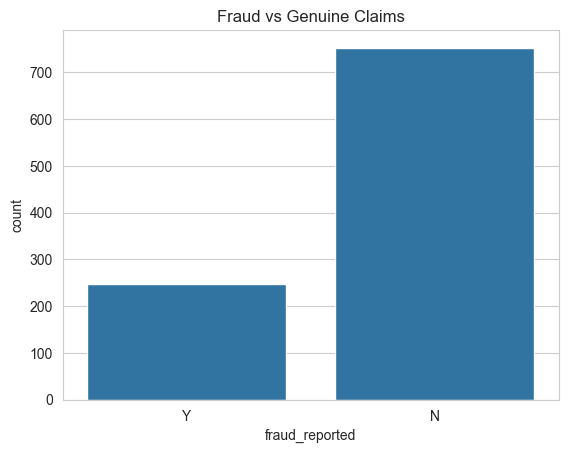

In [18]:
# Fraud distribution
sns.countplot(x="fraud_reported", data=df_clean)
plt.title("Fraud vs Genuine Claims")
plt.show()

In [19]:
# Fraud percentage
df_clean["fraud_reported"].value_counts(normalize=True) * 100

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

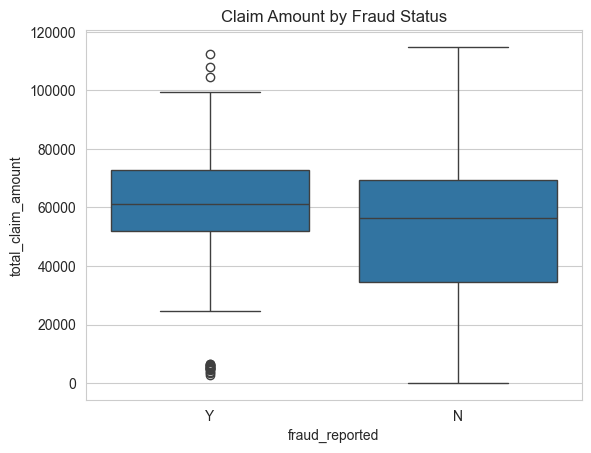

In [20]:
# Claim amount by fraud
sns.boxplot(x="fraud_reported", y="total_claim_amount", data=df_clean)
plt.title("Claim Amount by Fraud Status")
plt.show()

In [21]:
# Fraud by incident type
pd.crosstab(
    df_clean["incident_type"],
    df_clean["fraud_reported"],
    normalize="index"
) * 100

fraud_reported,N,Y
incident_type,,
Multi-vehicle Collision,72.792363,27.207637
Parked Car,90.476190,9.523810
Single Vehicle Collision,70.967742,29.032258
Vehicle Theft,91.489362,8.510638


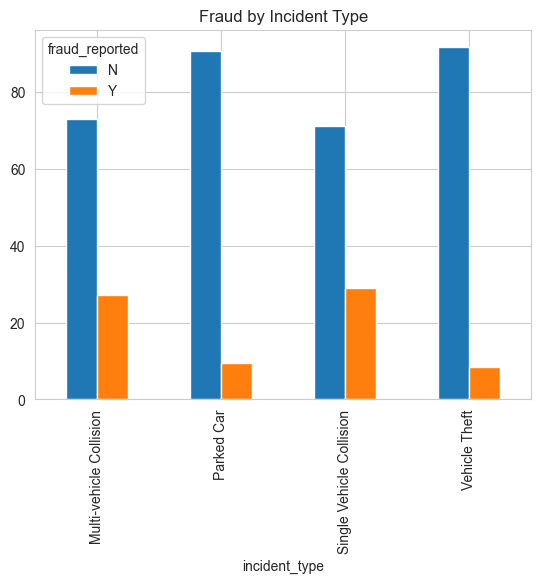

In [22]:
# Plot fraud by incident type
fraud_incident = pd.crosstab(
    df_clean["incident_type"],
    df_clean["fraud_reported"],
    normalize="index"
) * 100

fraud_incident.plot(kind="bar")
plt.title("Fraud by Incident Type")
plt.show()

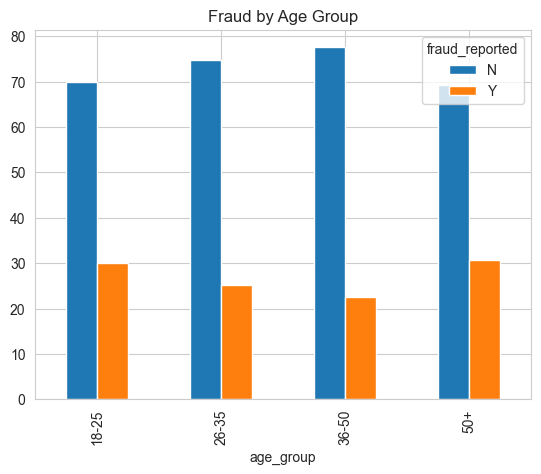

In [23]:
# Fraud by age group
fraud_age = pd.crosstab(
    df_clean["age_group"],
    df_clean["fraud_reported"],
    normalize="index"
) * 100

fraud_age.plot(kind="bar")
plt.title("Fraud by Age Group")
plt.show()

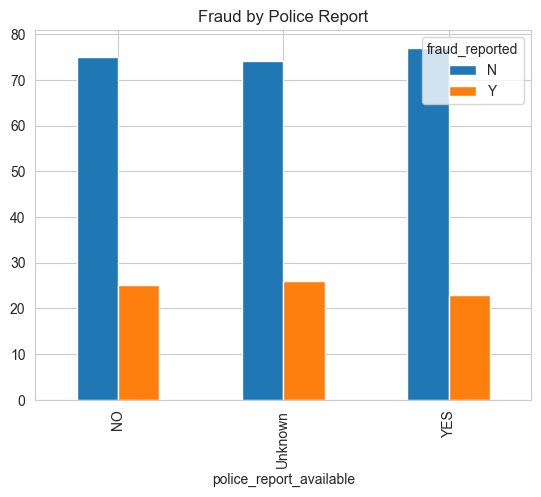

In [24]:
# Police report vs fraud
fraud_police = pd.crosstab(
    df_clean["police_report_available"],
    df_clean["fraud_reported"],
    normalize="index"
) * 100

fraud_police.plot(kind="bar")
plt.title("Fraud by Police Report")
plt.show()

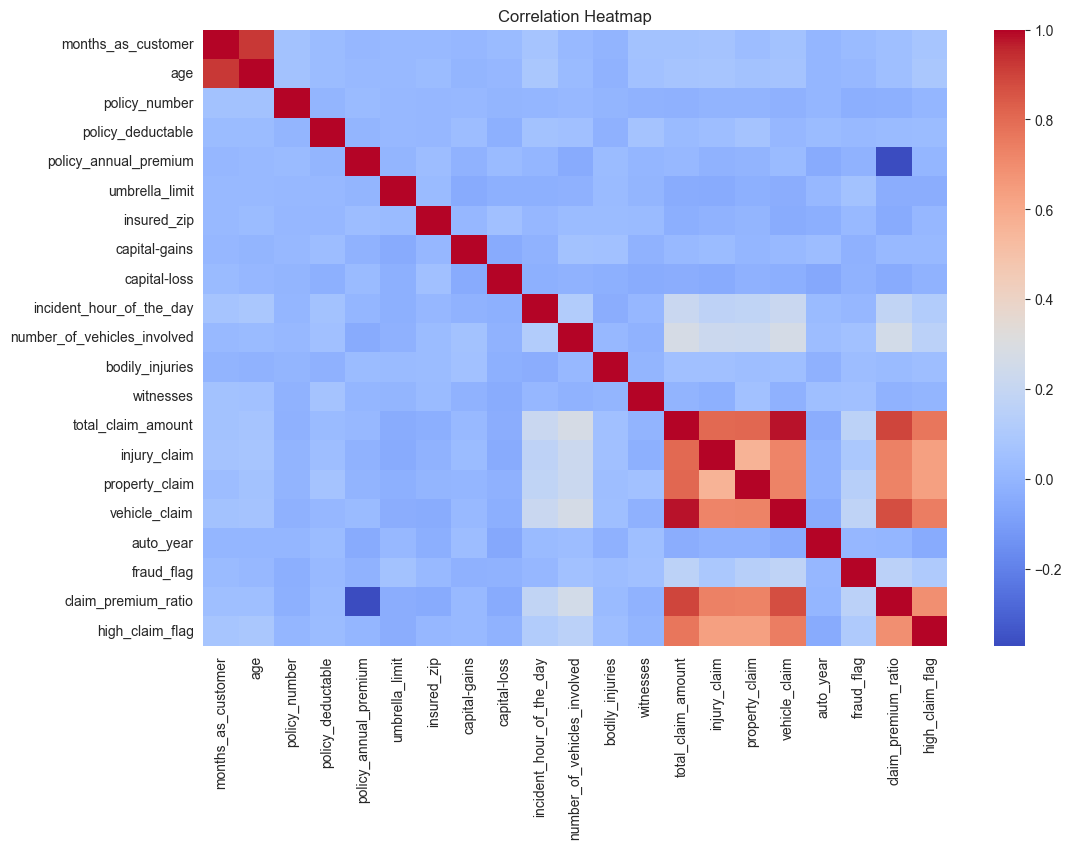

In [25]:
# Correlation heatmap
num_df = df_clean.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
##ML 

In [36]:
# Fresh copy
df_model = df_clean.copy()

In [37]:
# Drop columns not needed
drop_cols = [
    "fraud_reported",
    "policy_number",
    "policy_bind_date",
    "incident_date",
    "incident_location"
]

df_model = df_model.drop(columns=drop_cols)

In [38]:
# Convert category columns to object first
for col in df_model.select_dtypes(include="category").columns:
    df_model[col] = df_model[col].astype(str)

In [39]:
# One hot encode all text columns
df_model = pd.get_dummies(df_model, drop_first=True)

In [40]:
# Ensure all columns numeric
df_model = df_model.apply(pd.to_numeric)

In [41]:
# Split X and y
X = df_model.drop("fraud_flag", axis=1)
y = df_model["fraud_flag"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
#logistiuc Regression

In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000)
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.745
Precision: 0.55
Recall: 0.4


In [47]:
#random forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=200,
    max_depth=10
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [51]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.77
Precision: 0.6153846153846154
Recall: 0.43636363636363634


In [52]:
#feature Impoetance

In [53]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

print(importance)

incident_severity_Total Loss      0.067289
incident_severity_Minor Damage    0.065508
insured_hobbies_chess             0.047592
claim_premium_ratio               0.042935
total_claim_amount                0.041644
property_claim                    0.040503
vehicle_claim                     0.035372
insured_zip                       0.033890
injury_claim                      0.033135
months_as_customer                0.031033
dtype: float64


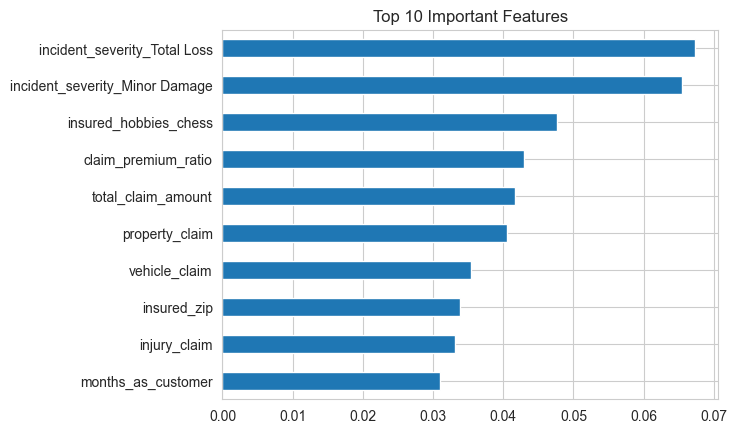

In [54]:
importance.sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

In [55]:
#confusion matrix

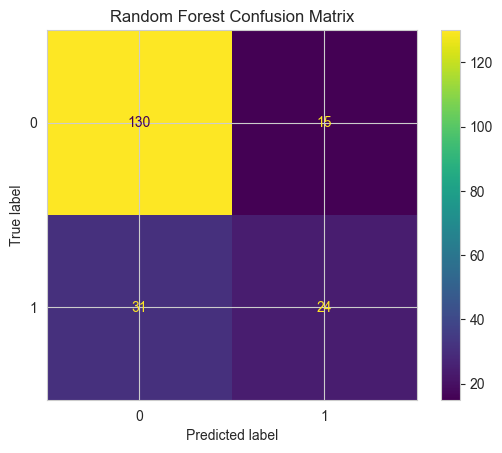

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [57]:
df_results = X_test.copy()

df_results["actual"] = y_test.values
df_results["fraud_score"] = rf.predict_proba(X_test)[:,1]

df_results[["actual", "fraud_score"]].head(10)


,actual,fraud_score
521,0,0.288958
737,0,0.234729
740,0,0.310434
660,0,0.226300
411,0,0.076707
678,0,0.310444
626,0,0.449663
513,1,0.515268
859,0,0.235695
136,0,0.101693


In [58]:
df_results["risk_tier"] = pd.cut(
    df_results["fraud_score"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

df_results["risk_tier"].value_counts()

risk_tier
Low       134
Medium     66
High        0
Name: count, dtype: int64

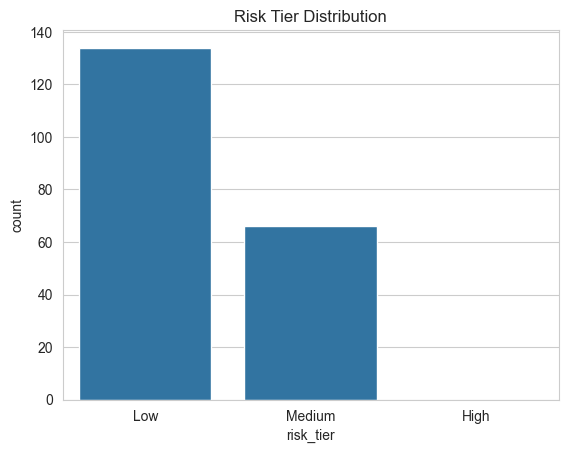

In [59]:
sns.countplot(x="risk_tier", data=df_results)
plt.title("Risk Tier Distribution")
plt.show()